In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio

In [21]:
df = pd.read_csv("customer_acquisition_data.csv")
df.head(3)

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164


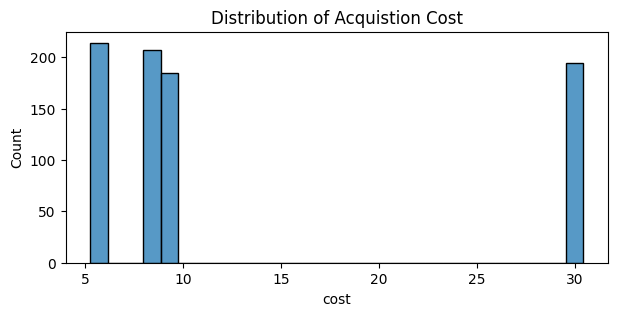

In [30]:
plt.figure(figsize=(7,3))
sns.histplot(x = "cost",data = df)
plt.title("Distribution of Acquistion Cost")
plt.show()

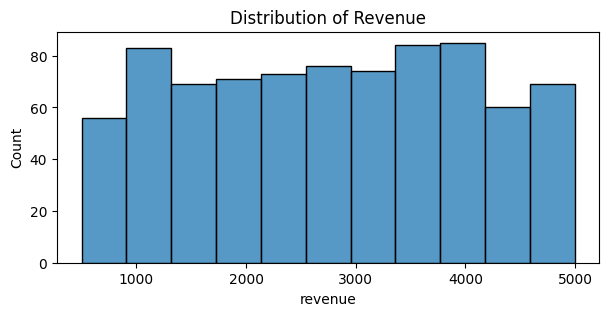

In [50]:
plt.figure(figsize=(7,3))
sns.histplot(x = "revenue",data = df)
plt.title('Distribution of Revenue')
plt.show()

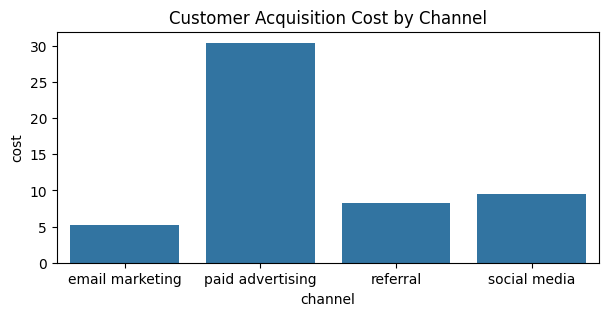

In [51]:
cost_by_channel = data.groupby('channel')['cost'].mean().reset_index()

plt.figure(figsize=(7,3))
sns.barplot(x='channel', y='cost',data = cost_by_channel)
plt.title('Customer Acquisition Cost by Channel')
plt.show()

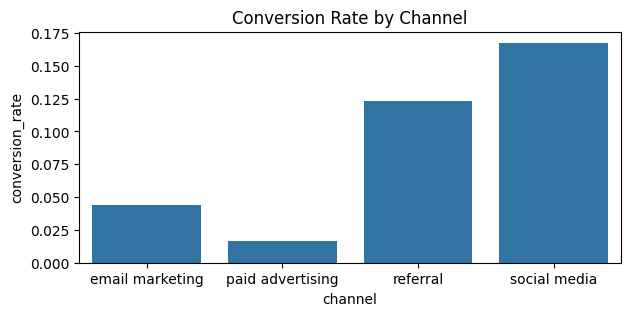

In [52]:
conversion_by_channel = data.groupby('channel')['conversion_rate'].mean().reset_index()

plt.figure(figsize=(7,3))
sns.barplot(x='channel', y='conversion_rate', data=conversion_by_channel)
plt.title('Conversion Rate by Channel')
plt.show()

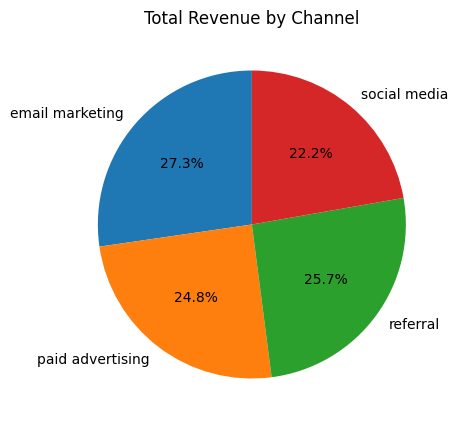

In [57]:
revenue_by_channel = data.groupby('channel')['revenue'].sum().reset_index()

plt.figure(figsize=(5, 5))
plt.pie(
    revenue_by_channel['revenue'],     # values
    labels=revenue_by_channel['channel'],  # names
    autopct='%1.1f%%',                 # show percentages
    startangle=90
)
plt.title("Total Revenue by Channel")
plt.show()

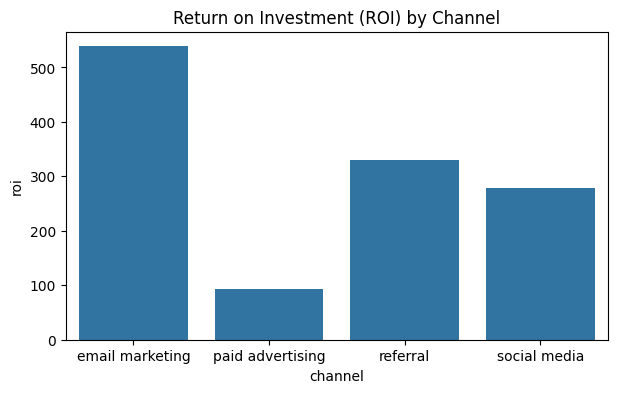

In [60]:
data['roi'] = data['revenue'] / data['cost']
roi_by_channel = data.groupby('channel')['roi'].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(x='channel', y='roi',data = roi_by_channel)
plt.title('Return on Investment (ROI) by Channel')
plt.show()

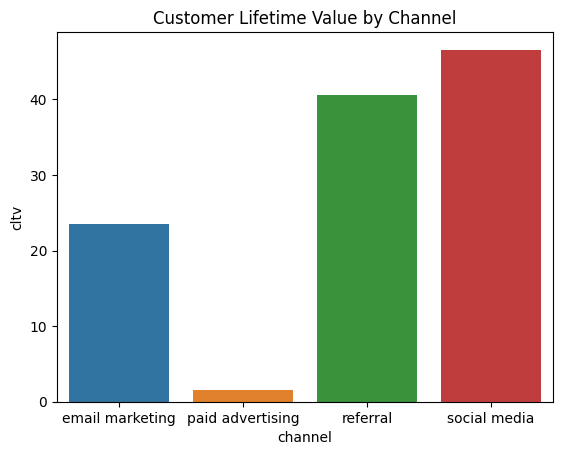

In [65]:
#CLTV = (revenue – cost) * conversion_rate / cost
data['cltv'] = (data['revenue'] - data['cost']) * data['conversion_rate'] / data['cost']
channel_cltv = data.groupby('channel')['cltv'].mean().reset_index()

sns.barplot(x='channel', y='cltv', hue="channel",data = channel_cltv,legend = False)
plt.title('Customer Lifetime Value by Channel')
plt.show()

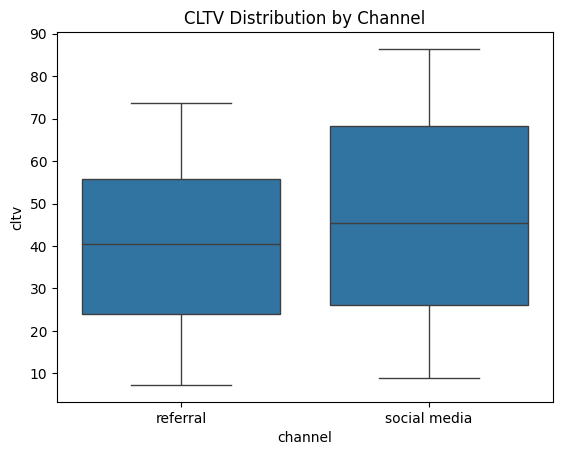

In [66]:
subset = data.loc[data['channel'].isin(['social media', 'referral'])]

sns.boxplot(data = subset, x='channel', y='cltv')
plt.title('CLTV Distribution by Channel')
plt.show()